# Natural Language Processing



This project will give you practical experience using Natural Language Processing techniques. This project is in three parts:
- in part 1) you will use a dataset in a CSV file
- in part 2) you will use the Wikipedia API to directly access content
on Wikipedia.
- in part 3) you will make your notebook interactive


### Part 1)



- The CSV file is available at https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv
- The file contains a list of famous people and a brief overview.
- The goal of part 1) is to ...
  1. Pick one person from the list ( the reference person ) and output 10 other people who's overview are "closest" to the reference person in a Natural Language Processing sense
  1. Also output the sentiment of the overview of the reference person



### Part 2)



- For the same reference person that you chose in Part 1), use the Wikipedia API to access the whole content of the reference person's Wikipedia page.
- The goal of Part 2) is to ...
  1. Print out the text of the Wikipedia article for the reference person
  1. Determine the sentiment of the text of the Wikipedia page for the reference person
  1. Collect the text of the Wikipedia pages from the 10 nearest neighbors from Part 1)
  1. Determine the nearness ranking of these 10 people to your reference person based on their entire Wikipedia page
  1. Compare, i.e. plot,  the nearest ranking from Step 1) with the Wikipedia page nearness ranking.  A difference of the rank is one means of comparison.



### Part 3)


Make an interactive notebook where a user can choose or enter a name and the notebook displays the 10 closest individuals.

In addition to presenting the project slides, at the end of the presentation each student will demonstrate their code using a famous person suggested by the other students that exists in the DBpedia set.


#Total Lines
42786 is one header and 42785 people.

In [1]:
!curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv | wc -l

42786


### Columns


1.   URI

2.   name
3.   text





In [2]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -1 |
tr , '\n' |
cat -n


     1	URI
     2	name
     3	text


#Digby Morrell
Text is clean and has no uppercase. Digby Morrell was the first data row.

In [3]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -2 |
tail -1 |
tr , '\n' |
cat -n


     1	<http://dbpedia.org/resource/Digby_Morrell>
     2	Digby Morrell
     3	digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he was the clubs leading goalkicker in 2000 at the age of 21 morrell was recruited to the australian football league by the kangaroos football club with its third round selection in the 2001 afl rookie draft as a forward he twice kicked five goals during his time with the kangaroos the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbaneafter the 2003 season morrell was traded along with david teague to the carlton football club in exchange for corey mckernan he played 32 games for the blues before being delisted at the end of 2005 he continued to play v

In [4]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv'
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv'

### Import Libraries


In [5]:
import pandas as pd

#### Read URL
https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv turn to data frame people_df

In [6]:
people_df = pd.read_csv(url)

#### Check DF



1.  people_df.shape
2.  people_df.head()
3.  people_df.tail()
4.  people_df.info()
5.  people_df.isna().sum()
6.  people_df.isna().sum().sum()
7.  people_df.describe()

In [7]:
people_df.shape

(42786, 3)

In [8]:
people_df.head()

,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...


In [9]:
people_df.tail()

,URI,name,text
42781,<http://dbpedia.org/resource/Motoaki_Takenouchi>,Motoaki Takenouchi,motoaki takenouchi born july 8 1967 saitama pr...
42782,<http://dbpedia.org/resource/Alan_Judge_(footb...,"Alan Judge (footballer, born 1960)",alan graham judge born 14 may 1960 is a retire...
42783,<http://dbpedia.org/resource/Eduardo_Lara>,Eduardo Lara,eduardo lara lozano born 4 september 1959 in c...
42784,<http://dbpedia.org/resource/Tatiana_Faberg%C3...,Tatiana Faberg%C3%A9,tatiana faberg is an author and faberg scholar...
42785,<http://dbpedia.org/resource/Kenneth_Thomas>,Kenneth Thomas,kenneth thomas born february 24 1938 was chief...


In [10]:
people_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42786 entries, 0 to 42785
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   URI     42786 non-null  object
 1   name    42786 non-null  object
 2   text    42786 non-null  object
dtypes: object(3)
memory usage: 1002.9+ KB


In [11]:
people_df.isna().sum()

,0
URI,0
name,0
text,0


In [12]:
people_df.isna().sum().sum()

np.int64(0)

In [13]:
people_df.describe()

,URI,name,text
count,42786,42786,42786
unique,42786,42785,42786
top,<http://dbpedia.org/resource/Kenneth_Thomas>,author),kenneth thomas born february 24 1938 was chief...
freq,1,2,1


### Unique values and sheared names
Unique values do not match count.  We have one less value in describe().
Two rows 787 and 17249 had names = author which is a fragment in the csv.  A parenthetical and a / were in the name.  Had to repair each name from URI.
Will .strip('<>').split('resource/')[-1].replace('_', '') [-1] is author


In [14]:
people_df.loc[[787, 17249], ['URI', 'name']]

,URI,name
787,<http://dbpedia.org/resource/James_Grieve_(tra...,author)
17249,<http://dbpedia.org/resource/Steve_Greenberg_(...,author)


In [15]:
uri_787 = people_df.loc[787, 'URI']        # .loc[row, column] → single value
uri_787

'<http://dbpedia.org/resource/James_Grieve_(translator/author)>'

In [16]:
people_df.loc[787, 'name'] = uri_787.strip('<>').split('resource/')[-1].replace('_', ' ')
uri_787

'<http://dbpedia.org/resource/James_Grieve_(translator/author)>'

In [17]:
uri_17249 = people_df.loc[17249, 'URI']
uri_17249

'<http://dbpedia.org/resource/Steve_Greenberg_(TV_personality/author)>'

In [18]:
people_df.loc[17249, 'name'] = uri_17249.strip('<>').split('resource/')[-1].replace('_', ' ')
uri_17249

'<http://dbpedia.org/resource/Steve_Greenberg_(TV_personality/author)>'

In [19]:
people_df.loc[[787, 17249], ['URI', 'name']]      # what are they named now?
(people_df['name'] == 'author)').sum()             # should be 0

np.int64(0)

### Empty
Names at loc 787, 17249 parsed incorrectly and created a fragment in the data set at the word 'author'. This made unique values one less, Removed the fragment and both names became unique.  The count and unique now match.

people_df[people_df['name'] == 'author'] return no results.


In [20]:
people_df[people_df['name'] == 'author)']

,URI,name,text


### Rows
Count and Unique URI and Name now match at 42786, repair worked and no fragments and no duplicates.

In [21]:
from urllib.parse import unquote
people_df['name'] = people_df['name'].apply(unquote)
print(people_df['name'].str.contains('%', na=False).sum())   # expect 0

0


In [22]:
people_df.describe()

,URI,name,text
count,42786,42786,42786
unique,42786,42786,42786
top,<http://dbpedia.org/resource/Kenneth_Thomas>,Kenneth Thomas,kenneth thomas born february 24 1938 was chief...
freq,1,1,1


Graphs

In [23]:
!pip install wordcloud

# Bag of Words matrix
Matrix shows five biographies, each column is a unique word, stop words are removed in this matrix. 5 rows display cells with the unique word being found in the biographies.  This matrix is a small slice of vocabulary.  

In [24]:
from sklearn.feature_extraction.text import CountVectorizer


# small sample so the count grid is readable
bow_demo_vec = CountVectorizer(stop_words='english')
bow_demo_matrix = bow_demo_vec.fit_transform(people_df['text'].head(5))

pd.DataFrame(bow_demo_matrix.toarray(),
             columns=bow_demo_vec.get_feature_names_out())

,10,18,1942,1963,1969,1973,1974,1975,1978,1979,...,won,work,worked,working,works,writers,year,years,york,zelazny
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,1,1,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,1,0,0,1,0,0,1,1,0,0
3,0,1,1,1,1,1,0,2,1,0,...,0,1,0,1,3,2,1,3,1,1
4,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,2,0,0,0


In [25]:
#code cell for both bar and cloud words use code
corpus_vec = CountVectorizer(stop_words='english')
corpus_matrix = corpus_vec.fit_transform(people_df['text'])
corpus_counts = corpus_matrix.sum(axis=0).A1
corpus_words = corpus_vec.get_feature_names_out()
corpus_freq = pd.Series(corpus_counts, index=corpus_words).sort_values(ascending=False)

### Top 20 Words

Across all the biographies, 42,786 total in BoW these are words use frequently.  These words are words like 'born', 'music', 'school' and others.  These are words that can be found in every biography in the corpus

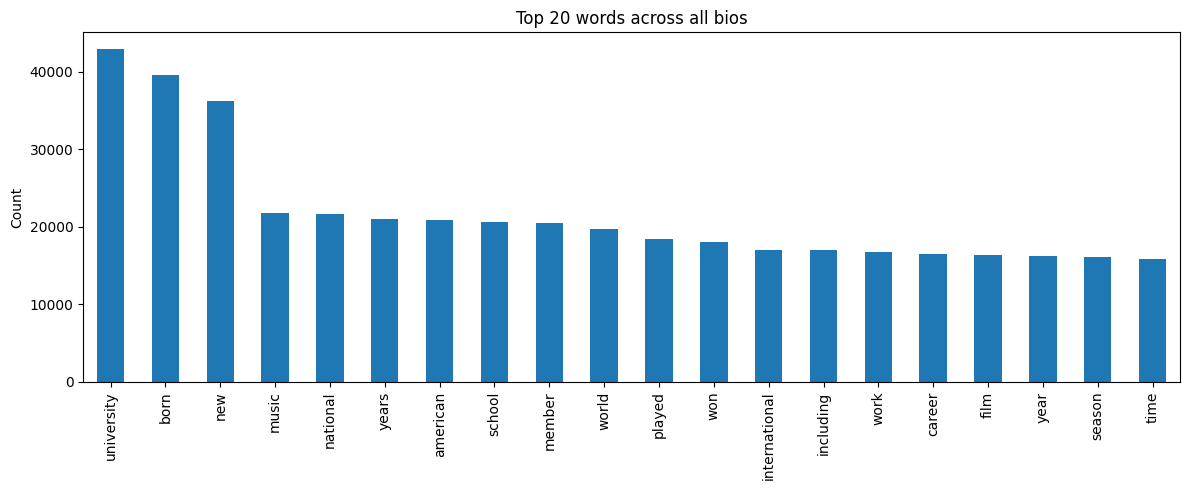

In [26]:
import matplotlib.pyplot as plt

corpus_freq.head(20).plot(kind='bar', figsize=(12, 5),
                          title='Top 20 words across all bios', ylabel='Count')
plt.tight_layout()
plt.show()

### Word cloud — same data, visual view
Similar to the bar chart, these word clouds show the most used words in the biographies and they are not unique to words.  Term Frequency-Inverse Document Frequency (TF-IDF) method assigns less value to these types of words, words that are rare and distinguished subjects are given better scores.

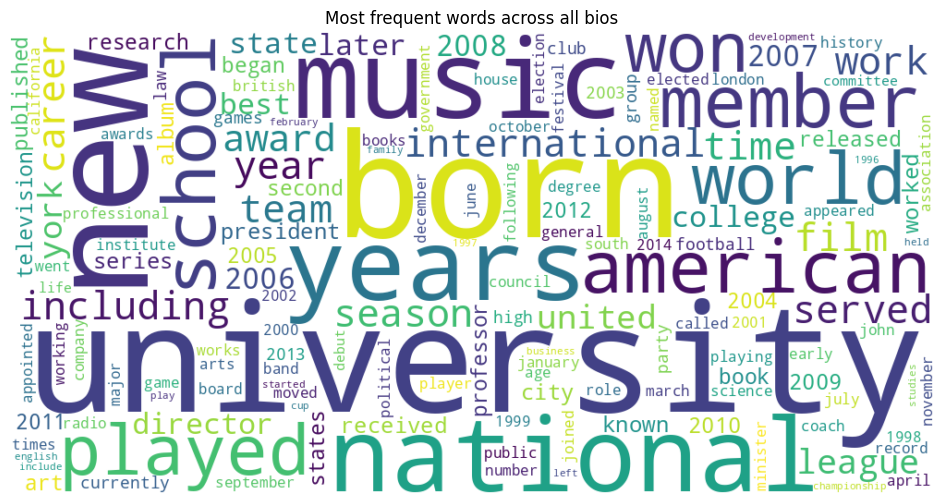

In [27]:
from wordcloud import WordCloud   # run !pip install wordcloud once, near your other installs

wc = WordCloud(width=1000, height=500, background_color='white')
wc.generate_from_frequencies(corpus_freq.head(150).to_dict())

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words across all bios')
plt.show()

### Import Library

from Sklearn and TfidfVectorizer
Use parameter stop_words rid text of common words that create noise; a, it, the etc.
Will store only non-zero cells using fit_transform format to avoid making a matrix 42,786 * 437,190 =18.7 billion cells would kill kernel.

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

### Reiterating

Unlike raw Bag of Words counts, TF-IDF down-weights the ubiquitous words seen in the
bar chart (born, university) and rewards rare, distinctive words — better for measuring
how similar two biographies are.

In [29]:

vectorizer = TfidfVectorizer(stop_words = 'english')

In [30]:
tfidf_matrix = vectorizer.fit_transform(people_df['text'])
tfidf_matrix.shape

(42786, 437190)

####  Cosine ignores magnitude and measures the angle between vectors.
The subject matters more than the word count and word distance which can be measured using Euclidean method for Nearest Neighbors but might indicate through measurement that the subjects are not related. Cosine is measuring angles and where the subjects vectors align in a matrix, avoiding the length of words in two measured documents.  

In [31]:
from sklearn.neighbors import NearestNeighbors

nn_model = NearestNeighbors(n_neighbors=11, metric='cosine')
nn_model.fit(tfidf_matrix)

NearestNeighbors(metric='cosine', n_neighbors=11)

In [32]:
people_df[people_df['name'].str.contains('pinky', case = False)]


,URI,name,text
31244,<http://dbpedia.org/resource/Pinky_Lai>,Pinky Lai,pinky lai hong kong born 20 march 1951 is an a...


### Neighbors to Pinky Lai Distance and Indices
kneighbors returns 11 results with distance in scientific notation. Pink Lai, is at the 0 mark or 2.22044605e-16 (0.000000000000000022). Neighbor 18576 IS 0.6016 distant from 0.

In [33]:
distances, indices = nn_model.kneighbors(tfidf_matrix[31244])
distances, indices

(array([[2.22044605e-16, 6.01669680e-01, 6.44689727e-01, 6.56732835e-01,
         6.81750038e-01, 6.82500621e-01, 6.91127594e-01, 6.95726243e-01,
         6.95900953e-01, 7.04118503e-01, 7.05797036e-01]]),
 array([[31244, 18576, 37909, 16508, 17330, 24787, 12415,  7969, 22231,
         24349, 30397]]))

### The 10 Neigbors of Pinky Lai
Pinky Lai was a automotive designer famous designer at Ford, BMW and Porsche. Born and raised in Quarry Bay, Hong Kong, Lai moved to Rome in 1972, where he studied and received a BA in industrial design at the Istituto Superiore per le Industrie Artistic he. After seeing an opening for car designer at Ford of Germany, in 1978 Lai received a two-year full scholarship for master's degree study on transportation design at the RCA Royal College of Art in London.

In 1980, winner and recipient of the John Ogier Memorial Design Bursary of the Royal Society of Arts.

**Reference**

[Pinky](https://en.wikipedia.org/wiki/Pinky_Lai#:~:text=Lai%20is%20noted%20for%20his,at%20Ford%2C%20BMW%20and%20Porsche.&text=During%20Lai's%20tenure%20at%20Porsche,Porsche%20987%20Boxster%20and%20Cayman.)

### Closest Neighbors
This are the indices of Pinky Lai's neighbors and text strings


In [34]:

people_df.loc[indices[0], ['name', 'text']]

,name,text
31244,Pinky Lai,pinky lai hong kong born 20 march 1951 is an a...
18576,Brigitte Borja de Mozota,brigitte borja de mozota started her career in...
37909,Josh Owen,josh owen born 1970 is an american industrial ...
16508,Tapani Hyvönen,tapani hyvnen born june 6 1947 is a finnish de...
17330,Patrick Le Quément,patrick g m le qument born 4 february 1945 in ...
24787,Mike Stott,mike stott was in 2006 professor of interactio...
12415,Peter Stevens (car designer),professor peter stevens born 1945 is a british...
7969,Garson Yu,garson yu is foundercreative director of yuco ...
22231,Mike Dempsey,mike dempsey trained in calligraphy and typogr...
24349,Christopher Simmons,christopher simmons born april 10 1973 is a ca...


In [35]:
people_df.loc[indices[0], ['name', 'text']].shape     # .loc[...] first, THEN .shape

(11, 2)

### Sentiment on Pinky Lai's bibliography
Python library for NLP - read more below.  Showing sentiment = polarity and subjectivity.  Polarity scores 0.07952 indicating that words in the biography are neutral and slightly positive, examples 'noted for' and 'chief designer.' Subjectivity scores at 0.37 and is mostly objective stating facts not indicating a tone or praise that is over the top.
 [Text Blobbing](https://textblob.readthedocs.io/en/dev/)


| Source | Polarity | Subjectivity |
| :--- | :--- | :--- |
| **Abstract** | 0.07952978056426332 | 0.370846394984326 |


In [36]:
from textblob import TextBlob

In [37]:
text_input = people_df.loc[31244, 'text']
blob = TextBlob(text_input)
print(blob.sentiment)
print(blob.polarity)

Sentiment(polarity=0.07952978056426332, subjectivity=0.370846394984326)
0.07952978056426332


## Wikipedia — do the polarity and subjectivity hold up on the full article?

In [38]:
!pip3 install wikipedia-api

## Unquote on Wiki API defined user

Use wikipediaapi, define user which is required. Build page title and strip 'resource/', replace '_" with ' '.  Output is Pinky Lai instead of <...resource/Pinky_Lai>.

In [39]:
import wikipediaapi
from urllib.parse import unquote

wikip = wikipediaapi.Wikipedia(user_agent='abduwakeel-nlp-project')

pinky_uri   = people_df.loc[31244, 'URI']
pinky_title =  pinky_uri.strip('<>').split('resource/')[-1].replace('_', ' ')  #  strip/split/replace chain
pinky_page  = wikip.page(pinky_title)

In [40]:
pinky_page.exists()

True

In [41]:
print(len(pinky_page.text))      #  words
print(pinky_page.text[:500])     # the opening

4043
Pinky Lai (賴平 Lai Ping, born 20 March 1951) is an automotive designer. Lai is noted for his design work at Ford, BMW and Porsche.
During Lai's tenure at Porsche from January 1989 until his retirement in 2014, he was chief designer responsible for the exterior designs of 996 series of the Porsche 911 as well as both the Porsche 987 Boxster and Cayman.

Background
Born and raised in Quarry Bay, Hong Kong, Lai moved to Rome in 1972, where he studied and received a BA in industrial design at the Ist


###      For Loop to print all neighbors
Use for loop to extract the 11 neighbors, and perform the same data cleaning on neighbors titles, also using unquote to decode ‘C3%A9.'  Use Boolean to denote if value is True or False.   Three pages were not found but titles were there.  False value on the following names Mike Stott, Brigitte Borja de Mozota and Yanic Simard.  


In [42]:
wiki_texts = {}

for URI in people_df.loc[indices[0], "URI"]:
    title = unquote(URI.strip("<>").split("resource/")[-1].replace("_", " "))
    page = wikip.page(title)
    print(title, "→", page.exists())
    if page.exists():
        wiki_texts[title] = page.text
    else:
        wiki_texts[title] = "Page not found"

Pinky Lai → True
Brigitte Borja de Mozota → False
Josh Owen → True
Tapani Hyvönen → True
Patrick Le Quément → True
Mike Stott → False
Peter Stevens (car designer) → True
Garson Yu → True
Mike Dempsey → True
Christopher Simmons → True
Yanic Simard → False


# Total
Seven neighbors + Pinky. The 3 missing values came back as False.  The titles are there but the bios are not.

In [43]:
len(wiki_texts)          # should be 11 keys
sum(1 for v in wiki_texts.values() if v != "Page not found")   # should be 8

8

### Sentiment on the abstract vs full page

The sentiment is stable across both sources. Full page vs. abstract barely moved the needle — both say "neutral-to-mildly-positive, mostly objective." That answers the deliverable's question ("does the sentiment hold up?") yes.
Polarity in the full article rose by 0.027.  More words in the full article.

| Source | Polarity | Subjectivity |
| :--- | :--- | :--- |
| **Abstract** (~200 words) | 0.0795 | 0.371 |
| **Full article** (~4043 chars) | 0.1063 | 0.304 |


In [44]:
pinky_full = wiki_texts["Pinky Lai"]     # look up his article in the dict
blob = TextBlob(pinky_full)
print(blob.sentiment)

Sentiment(polarity=0.10625, subjectivity=0.30364583333333334)


### New list of names

Excluded the names that were missing full articles.  Used for loop and continue to append name and text.

In [45]:
kept_names = []
kept_texts = []


for name, text in wiki_texts.items():
    if text == "Page not found":
        continue
    kept_names.append(name)      # the person's name
    kept_texts.append(text)      # their full article


### New name list
8 total

In [46]:

len(kept_names), len(kept_texts)     # both 8?
kept_names                            # Pinky first, missing 3 absent?

['Pinky Lai',
 'Josh Owen',
 'Tapani Hyvönen',
 'Patrick Le Quément',
 'Peter Stevens (car designer)',
 'Garson Yu',
 'Mike Dempsey',
 'Christopher Simmons']

### Vectorizer
Fit a new TfidVectorizer on the 8 full Wiki pages in the neighbors list.  New matrix is 8 rows x 941 words.  The previous TF-IDF was on the total bios of 42786 rows x 437190 columns of unique words.

In [47]:
full_vectorizer = TfidfVectorizer(stop_words='english')
full_matrix = full_vectorizer.fit_transform(kept_texts)
full_matrix.shape

(8, 941)

###Nearest neighbors
8 total using cosine.


In [48]:
full_nn = NearestNeighbors(n_neighbors= 8, metric='cosine')
full_nn.fit(full_matrix)

NearestNeighbors(metric='cosine', n_neighbors=8)

### Distance

In [49]:
full_distances, full_indices = full_nn.kneighbors(full_matrix[0])
full_indices

array([[0, 2, 1, 5, 7, 4, 3, 6]])

In [50]:
full_distances

array([[0.        , 0.80219916, 0.8189879 , 0.86230309, 0.86593741,
        0.86903257, 0.87901682, 0.99407058]])

Full page ranking

In [51]:
[kept_names[i] for i in full_indices[0]]

['Pinky Lai',
 'Tapani Hyvönen',
 'Josh Owen',
 'Garson Yu',
 'Christopher Simmons',
 'Peter Stevens (car designer)',
 'Patrick Le Quément',
 'Mike Dempsey']

In [52]:
full_ranking = [kept_names[i] for i in full_indices[0]]


In [53]:
rank_diffs = []
for name in kept_names:                       # walk each person
    abstract_rank = kept_names.index(name)
    full_rank     = full_ranking.index(name)
    rank_diffs.append(full_rank - abstract_rank)   # or abstract - full; pick a convention
print(rank_diffs)
print(sum(rank_diffs))

[0, 1, -1, 3, 1, -2, 1, -3]
0


### Build Plot
This shows the neighbors in the 8 bios and how close or how far they are from Pinky.  Neighbors with positive values are further away than neighbors with negative values.  Patrick Le Quément is a well-known car designer for Renault.  He is close to +3 and despite similar fields his bio has is unique just as Pinky's bio, so the commonality is less between them.  Other neighbors like Christopher Simmons share more common features in the bio between him and Pinky.  His neighbor rank is close to -3  indicating commonality between their bios, especially in design.

In [54]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

Text(0.5, 1.0, "How full articles re-ranked Pinky's neighbors")

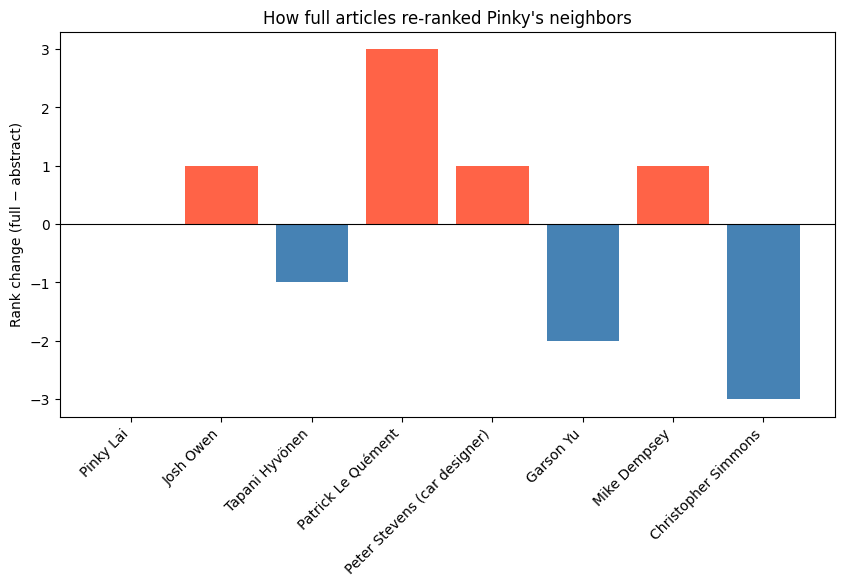

In [55]:
colors = ['tomato' if d > 0 else 'steelblue' for d in rank_diffs]

plt.figure(figsize=(10, 5))
plt.bar(kept_names, rank_diffs, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Rank change (full − abstract)')
plt.title("How full articles re-ranked Pinky's neighbors")


In [56]:


words = full_vectorizer.get_feature_names_out()
row = full_matrix[0].toarray().flatten()      # Pinky's row (row 0), as a flat array of 941 weights
top_idx = row.argsort()[-8:][::-1]            # positions of the 8 highest weights
top_words = words[top_idx]                    # the words at those positions
top_scores = row[top_idx]                     # their weights

print(kept_names[0])
for w, s in zip(top_words, top_scores):
    print(f"  {w}: {s:.3f}")

Pinky Lai
  911: 0.402
  design: 0.249
  porsche: 0.248
  carrera: 0.186
  lai: 0.186
  kong: 0.179
  hong: 0.179
  university: 0.156


### Top TF-IDF words
These words are the top words in the articles, and they are charted for each person.  Some of the words are unique like the name of the person, they rank at the top because they are unique to the bio.  Signature brands (Quément, Renault, Porsche) are unique to the person’s bio and not shared across biographies. Some similarities in the graph indicate how the model determined rank, like the word design shared across four bios.

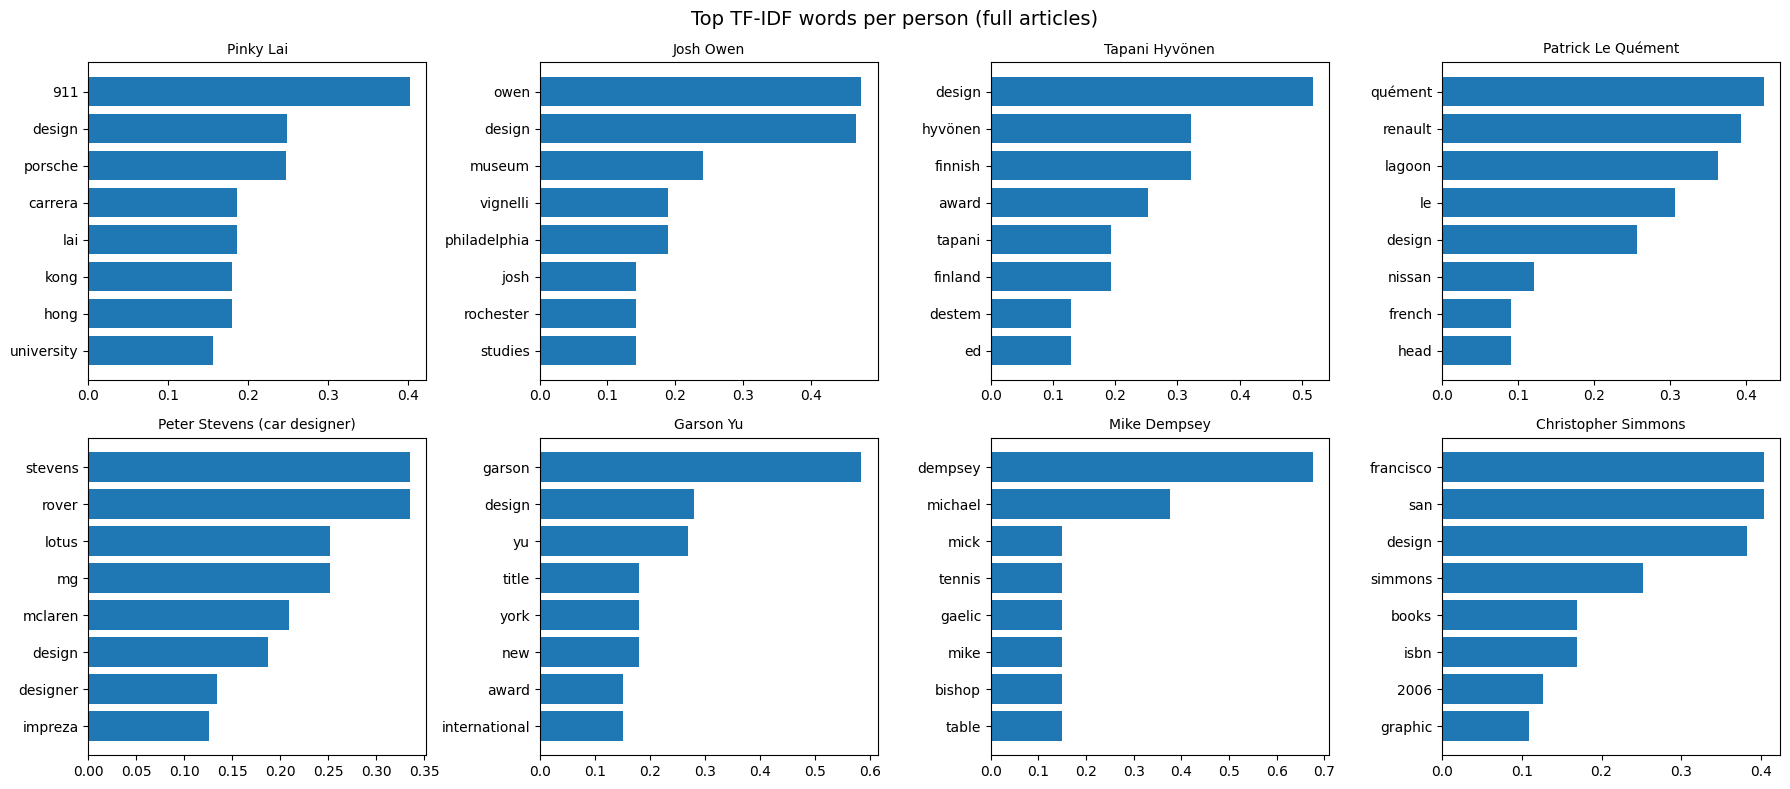

In [57]:


words = full_vectorizer.get_feature_names_out()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))    # 2 rows × 4 cols = 8 panels
axes = axes.flatten()                               # makes the grid easy to loop over

for i, name in enumerate(kept_names):
    row = full_matrix[i].toarray().flatten()
    top_idx = row.argsort()[-8:][::-1]
    top_words = words[top_idx]
    top_scores = row[top_idx]

    axes[i].barh(top_words[::-1], top_scores[::-1])   # horizontal bars, highest on top
    axes[i].set_title(name, fontsize=10)

fig.suptitle('Top TF-IDF words per person (full articles)', fontsize=14)
plt.tight_layout()
plt.show()

"""Function for neighbors"""

In [58]:
def find_neighbors(name):
    '''
    Given a name, return the 10 closest people from the dataset.

    Steps: case-insensitive search for the name, then guard two edge cases —
    if no match, report not-found; if multiple matches, list them and ask the
    user to be specific. On a single clean match, pull that person's TF-IDF
    vector, query the nearest-neighbors model, drop the self-match, and return
    the 10 neighbor names.
    '''
    matches = people_df[people_df['name'].str.contains(name, case=False, na=False)]

    if matches.empty:
        print(f"'{name}' not found in the dataset. Try another name.")
        return                                    # stop — don't reach row_pos

    if len(matches) > 1:                          # ambiguity guard
        print(f"Multiple matches for '{name}'. Which did you mean?")
        for n in matches['name']:
            print("  -", n)
        return

    row_pos = matches.index[0]
    person_vector = tfidf_matrix[row_pos]
    distances, indices = nn_model.kneighbors(person_vector)
    neighbor_positions = indices[0][1:]           # drop self-match at position 0
    return people_df.loc[neighbor_positions, 'name']

Test

In [59]:
find_neighbors('Pinky Lai')

,name
18576,Brigitte Borja de Mozota
37909,Josh Owen
16508,Tapani Hyvönen
17330,Patrick Le Quément
24787,Mike Stott
12415,Peter Stevens (car designer)
7969,Garson Yu
22231,Mike Dempsey
24349,Christopher Simmons
30397,Yanic Simard


In [60]:
find_neighbors('Zxqwerty')

'Zxqwerty' not found in the dataset. Try another name.


In [61]:
!pip install networkx
import networkx as nx


In [62]:
from sklearn.metrics.pairwise import cosine_similarity
sim = cosine_similarity(full_matrix)      # 8×8, every pair


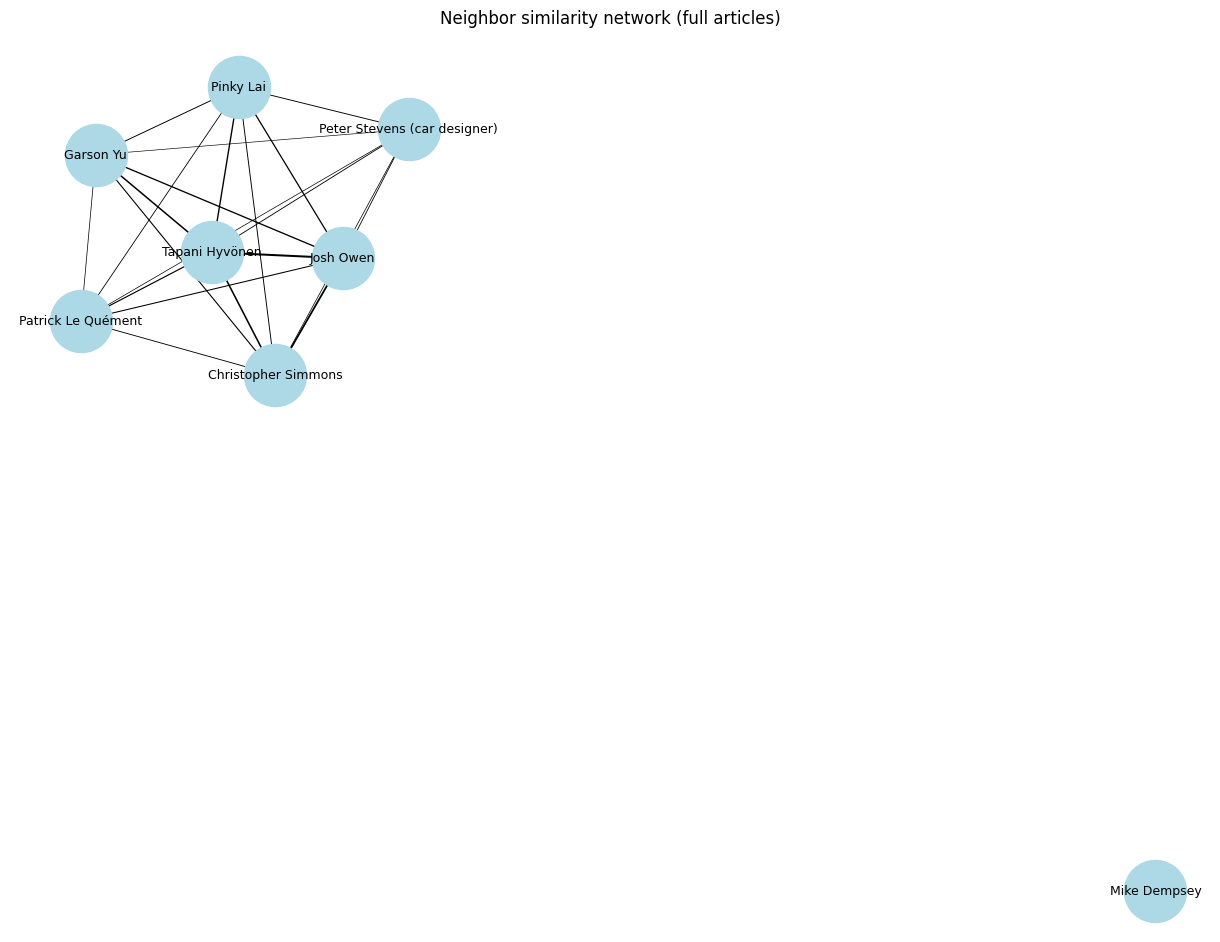

In [63]:
G = nx.Graph()
for i, name in enumerate(kept_names):
    G.add_node(name)

# add an edge between every pair, weighted by similarity (skip self and weak links)
for i in range(len(kept_names)):
    for j in range(i+1, len(kept_names)):
        if sim[i, j] > 0.05:                    # threshold: skip near-zero links
            G.add_edge(kept_names[i], kept_names[j], weight=sim[i, j])

pos = nx.spring_layout(G, seed=42)              # force-directed positions
weights = [G[u][v]['weight'] * 5 for u, v in G.edges()]   # edge thickness

plt.figure(figsize=(12, 9))
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=2000, width=weights, font_size=9)
plt.title("Neighbor similarity network (full articles)")
plt.show()

In [64]:
people_df['name'].str.contains('%', na=False).sum()    # expect 0 (encoding clean)
                                    # expect 11

np.int64(0)

In [65]:
tfidf_matrix.shape                                      # expect (42786, 437190)


(42786, 437190)

In [66]:
len(wiki_texts)

11

Input with while loop

In [67]:

while True:
  user_name = input("Enter a name (or 'quit' to stop): ").strip()

  if user_name.strip().lower() in ("quit", "stop"):       # the escape hatch
        print("Goodbye!")
        break                               # exits the loop cleanly

  result = find_neighbors(user_name)
  if result is not None:
   print(result)

Enter a name (or 'quit' to stop): quit
Goodbye!
